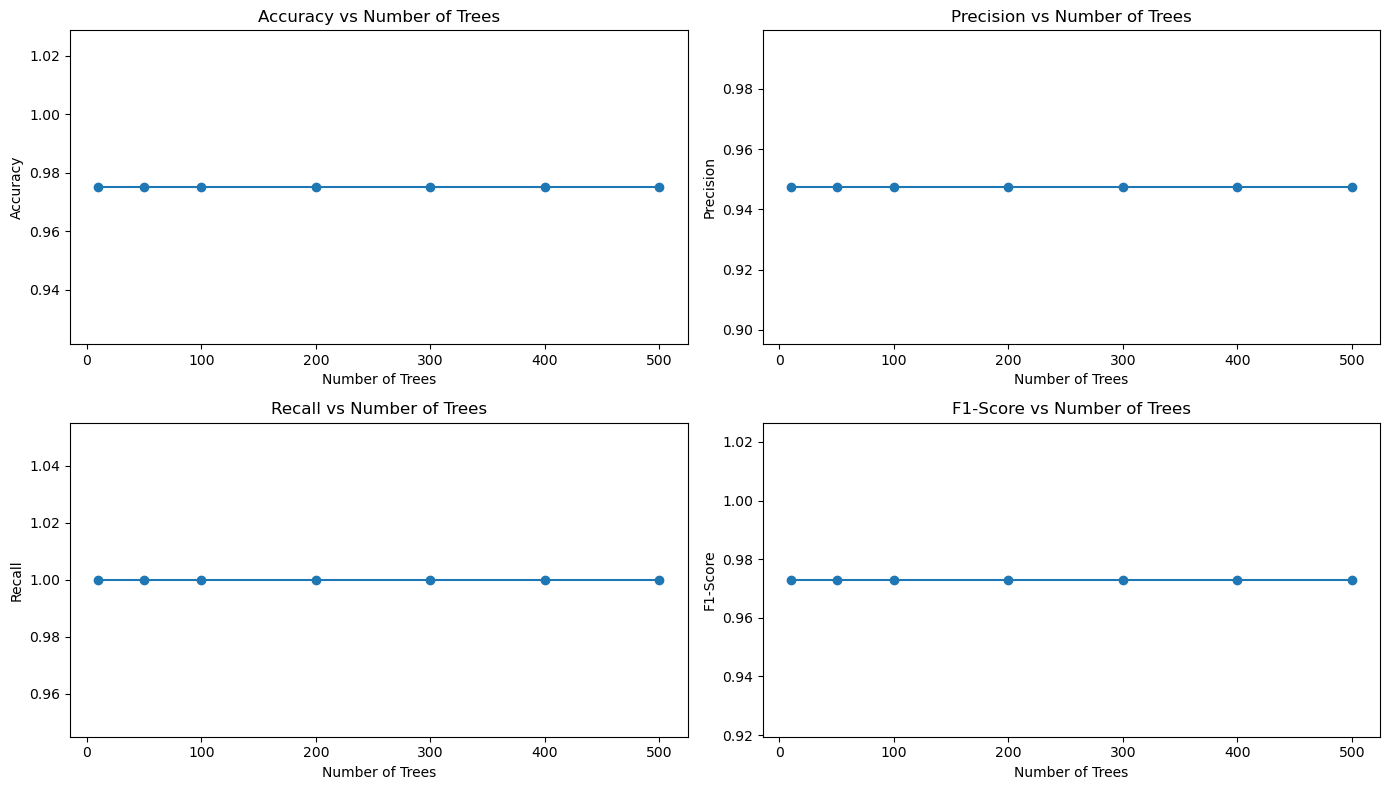

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# Load the dataset

data = pd.read_csv('advertising.csv')

# Create binary target variable
median_sales = data['Sales'].median()
data['Sales'] = np.where(data['Sales'] > median_sales, 1, 0)

# Split the data into features and target
X = data.drop('Sales',axis=1)
y = data['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the range of number of trees to test
n_trees = [10, 50, 100, 200, 300, 400, 500]

# Initialize lists to store evaluation metrics
accuracies = []
precisions = []
recalls = []
f1_scores = []

# Implement the Random Forest algorithm with different numbers of trees
for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    
    accuracies.append(accuracy_score(y_test, y_pred))
    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

# Plot the results
plt.figure(figsize=(14, 8))

plt.subplot(2, 2, 1)
plt.plot(n_trees, accuracies, marker='o')
plt.title('Accuracy vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')

plt.subplot(2, 2, 2)
plt.plot(n_trees, precisions, marker='o')
plt.title('Precision vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Precision')

plt.subplot(2, 2, 3)
plt.plot(n_trees, recalls, marker='o')
plt.title('Recall vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('Recall')

plt.subplot(2, 2, 4)
plt.plot(n_trees, f1_scores, marker='o')
plt.title('F1-Score vs Number of Trees')
plt.xlabel('Number of Trees')
plt.ylabel('F1-Score')

plt.tight_layout()
plt.show()
